In [17]:
!python3 -m venv sailing-env
!source sailing-env/bin/activate
!pip install -r requirements.txt

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from src.utils.agent_utils import save_dqn_agent

In [20]:
import sys
import os
import numpy as np
import random
from collections import deque
import pickle
import math
import time

# Add the src directory to the path
sys.path.append(os.path.abspath('../src'))
sys.path.append(os.path.abspath('..'))

# Import the BaseAgent class
from src.agents.base_agent import BaseAgent

In [21]:
from src.env_sailing import SailingEnv
from src.wind_scenarios import get_wind_scenario

In [28]:
class NeuralNetwork:
    def __init__(self, input_size=6, hidden_size_1=256, hidden_size_2 = 128, hidden_size_3 =64,  output_size=9 ,learning_rate=0.001):
        super().__init__()
        self.np_random = np.random.default_rng()
        self.learning_rate = learning_rate
        # Linear parameters
        self.W1 = np.random.randn(input_size, hidden_size_1) * np.sqrt(2./input_size)
        self.b1 = np.zeros((1, hidden_size_1))
        self.W2 = np.random.randn(hidden_size_1, hidden_size_2) * np.sqrt(2./hidden_size_1)
        self.b2 = np.zeros((1, hidden_size_2))  
        self.W3 = np.random.randn(hidden_size_2, hidden_size_3) * np.sqrt(2./hidden_size_2)
        self.b3 = np.zeros((1, hidden_size_3))  
        self.W4 = np.random.randn(hidden_size_3, output_size) * np.sqrt(2./hidden_size_3)
        self.b4 = np.zeros((1, output_size))

    def forward(self, X):
        self.X = np.array(X)

        self.l1 = np.dot(X, self.W1) + self.b1
        self.relu1 = np.maximum(0, self.l1) 
        self.l2 = np.dot(self.relu1, self.W2) + self.b2
        self.relu2 = np.maximum(0, self.l2) 
        self.l3 = np.dot(self.relu2, self.W3) + self.b3
        self.relu3 = np.maximum(0, self.l3) 
        self.l4 = np.dot(self.relu3, self.W4) + self.b4
        return self.l4

    def backward(self, y_pred, y_true):
        batch_size = y_pred.shape[0]

        dl4 = 2 * (y_pred - y_true) / batch_size #mse
        dW4 = np.dot(self.relu3.T, dl4)
        db4 = np.sum(dl4, axis=0, keepdims=True)

        drelu3 = np.dot(dl4, self.W4.T)
        dl3 = drelu3 * (self.l3 > 0)
        dW3 = np.dot(self.relu2.T, dl3)
        db3 = np.sum(dl3, axis=0, keepdims=True)

        drelu2 = np.dot(dl3, self.W3.T)
        dl2 = drelu2 * (self.l2 > 0)
        dW2 = np.dot(self.relu1.T, dl2)
        db2 = np.sum(dl2, axis=0, keepdims=True)

        drelu1 = np.dot(dl2, self.W2.T)
        dl1 = drelu1 * (self.l1 > 0)
        dW1 = np.dot(self.X.T, dl1)
        db1 = np.sum(dl1, axis=0, keepdims=True)

        for grad in [dW1, db1, dW2, db2, dW3, db3, dW4, db4]:
            np.clip(grad, -1, 1, out=grad)

        self.W4 -= self.learning_rate * dW4
        self.b4 -= self.learning_rate * db4
        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1


    def copy_weights(self):
        return {
            'W1': self.W1.copy(), 'b1': self.b1.copy(),
            'W2': self.W2.copy(), 'b2': self.b2.copy(),
            'W3': self.W3.copy(), 'b3': self.b3.copy(),
            'W4': self.W4.copy(), 'b4': self.b4.copy()
        }  

    def update_weights(self, weights):
        self.W1 = weights['W1'].copy()
        self.b1 = weights['b1'].copy()
        self.W2 = weights['W2'].copy()
        self.b2 = weights['b2'].copy()
        self.W3 = weights['W3'].copy()
        self.b3 = weights['b3'].copy()
        self.W4 = weights['W4'].copy()
        self.b4 = weights['b4'].copy()

In [29]:
class DQNAgent(BaseAgent):
    def __init__(self, hidden_size_1=256, hidden_size_2=128, hidden_size_3=64, memory_buffer = 100000, learning_rate=0.001, discount_factor=0.9, exploration_rate=0.1):
        super().__init__()
        self.np_random = np.random.default_rng()
        self.buffer_random = random.Random()        

        # Learning parameters
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate

        self.policy_net = NeuralNetwork(14, hidden_size_1, hidden_size_2, hidden_size_3, 9, self.learning_rate)
        self.target_net = NeuralNetwork(14, hidden_size_1, hidden_size_2, hidden_size_3, 9, self.learning_rate)
        self.update_weights_target() #pour initialiser avec les mêmes poids

        self.buffer = deque(maxlen=memory_buffer) #pour stocker en mémoire

    def get_features(self, observation):
        x, y = observation[0], observation[1]
        vx, vy = observation[2], observation[3]
        wx, wy = observation[4], observation[5]
        #flattened_wind_field = observation[6:6+32768].reshape(2, 128, 128)
        flattened_world = observation[6+32768:]

        features = []
        #create new features 

        #feature of danger
        direction = [(0,1), (1,1), (1,0), (1,-1), (0,-1), (-1,-1), (-1,0), (-1,1)]
        #on choisit une direction et on crée une feature de danger par rapport à l'ile
        for direction_x, direction_y in direction: 
            danger = 0
            for distance in range(1,21):
                new_x = int(x + direction_x*distance)
                new_y = int(y + direction_y*distance)
                if 0 <= new_x < 128 and 0<= new_y < 128:
                    if flattened_world[new_x*128 + new_y] == 1:
                        danger = (21 - distance)/21 
                        break
            features.append(danger)
        
        #feature on the wind information
        #to do

        return np.array([x/128,y/128, vx, vy, wx, wy] + features)

    def act(self, observation):
        """Choose an action using epsilon-greedy policy."""
        state = self.get_features(observation).reshape(1, -1)
        # Epsilon-greedy action selection
        if self.np_random.random() < self.exploration_rate:
            return self.np_random.integers(0, 9)
        else:
            q_values = self.policy_net.forward(state)
            return int(np.argmax(q_values))

    def learn(self, observation, action, reward, next_observation, batch_size, done):
        """Update q_values based on observed transition."""
        #Store in buffer
        state = self.get_features(observation)
        next_state = self.get_features(next_observation)
        self.buffer.append((state, action, reward, next_state, done))

        if len(self.buffer) >= batch_size:
            batch = self.buffer_random.sample(self.buffer, batch_size)
            states, actions, rewards, next_states, dones = zip(*batch) #pour mettre au bon format
            
            # Calcul of Q values
            current_q_values = self.policy_net.forward(states)
            next_q_values = self.target_net.forward(next_states)
            
            targets = current_q_values.copy()
            for i in range(batch_size):
                target = rewards[i]
                if not dones[i]:
                    target += self.discount_factor * np.max(next_q_values[i])
                targets[i, actions[i]] = target
            self.policy_net.forward(states) 
            self.policy_net.backward(current_q_values, targets)
        
    def reset(self):
        """Reset the agent for a new episode."""
        # Nothing to reset
        pass
        
    def seed(self, seed=None):
        """Set the random seed."""
        self.np_random = np.random.default_rng(seed)
        self.buffer_random = random.Random(seed)
        self.policy_net.rng = np.random.default_rng(seed)
        self.target_net.rng = np.random.default_rng(seed) 
        
    def save(self, path):
        """Save the weights to a file."""
        with open(path, 'wb') as f:
            pickle.dump(self.policy_net.copy_weights(), f)
            
    def load(self, path):
        """Load the weights from a file."""
        with open(path, 'rb') as f:
            self.policy_net.update_weights(pickle.load(f))
            self.update_weights_target()
    
    def update_weights_target(self):
        self.target_net.update_weights(self.policy_net.copy_weights())

In [30]:
dqn_agent = DQNAgent(learning_rate=0.0002, discount_factor=0.99, exploration_rate=0.8)
max_steps = 500

np.random.seed(42)
dqn_agent.seed(42)

scenarios = ['training_1', 'training_2', 'training_3']
num_episodes = 4000
batch_size = 128
target_update_freq = 100

rewards_history = []
steps_history = []
success_history = []

best_avg_steps = 500
best_success = 0

start_time = time.time()
print(f"Starting full training with {num_episodes} episodes across 3 scenarios...")

for episode in range(num_episodes):
    scenario = scenarios[episode % 3]
    env = SailingEnv(**get_wind_scenario(scenario))
    goal = env.goal_position.copy()
    
    observation, info = env.reset(seed=episode)
    prev_dist = np.linalg.norm(info['position'] - goal)
    total_reward = 0
    previous_action = None

    for step in range(max_steps):
        action = dqn_agent.act(observation)
        next_observation, reward, done, truncated, info = env.step(action)
        
        #Reward 

        #VMG reward
        curr_speed = math.sqrt((info['velocity'][0])**2 + (info['velocity'][1])**2 )
        curr_angle_boat = math.atan2(info['velocity'][1], info['velocity'][0])
        curr_angle_to_goal = math.atan2(goal[1] - info['position'][1], goal[0] - info['position'][0])
        theta = curr_angle_boat - curr_angle_to_goal
        vmg_reward = curr_speed * math.cos(theta)

        #angle wind reward 
        curr_angle_wind = math.degrees(math.atan2(info['wind'][1], info['wind'][0]))
        curr_angle_boat = math.degrees(math.atan2(info['velocity'][1], info['velocity'][0]))
        curr_angle = abs(curr_angle_wind - curr_angle_boat)
        if curr_angle > 180 :
            curr_angle = 360 - curr_angle
        curr_angle = 180 - curr_angle
        if curr_angle < 40:
            wind_reward = -1.0
        elif curr_angle < 50:
            wind_reward = 0.4
        elif curr_angle < 80:
            wind_reward = 0.6
        elif curr_angle < 100:
            wind_reward = 1.0
        elif curr_angle < 150:
            wind_reward = 0.8
        else:
            wind_reward = 0.4
        
        #speed reward 
        speed_reward = -0.5

        #change action reward 
        action_reward = 0
        if previous_action != None and action != previous_action :
            action_reward = -0.2

        #distance reward
        curr_dist = np.linalg.norm(info['position'] - goal) 
        distance_reward = prev_dist - dqn_agent.discount_factor*curr_dist

        if step == 50 and (episode+1)%500 == 0:
            print(f"Distance: {distance_reward:.4f}")
            print(f"VMG: {vmg_reward:.4f}")
            print(f"Wind: {wind_reward:.4f}")
            print(f"Action Pen: {action_reward:.4f}")
        shaped_reward = reward + speed_reward + 0*distance_reward + 3*vmg_reward + 0.5*wind_reward + action_reward
        if step == 50 and (episode+1)%500 == 0:
            print(f"TOTAL STEP REWARD: {shaped_reward:.4f}")


        if done and not info.get('is_stuck', False):
            shaped_reward += (max_steps - step) * 0.2
        if info.get('is_stuck', False):
            shaped_reward = -50.0
        prev_dist = curr_dist
        
        dqn_agent.learn(observation, action, shaped_reward, next_observation, batch_size, done)
        observation = next_observation
        previous_action = action
        total_reward += reward
        
        if done or truncated:
            break

    rewards_history.append(total_reward)
    steps_history.append(step + 1)
    is_victory = done and not info.get('is_stuck', False)
    success_history.append(is_victory)

    dqn_agent.exploration_rate = max(0.05, dqn_agent.exploration_rate * 0.9985)

    if episode == 1000:
        dqn_agent.policy_net.learning_rate = 0.0001
        dqn_agent.target_net.learning_rate = 0.0001
    elif episode == 2000:
        dqn_agent.policy_net.learning_rate = 0.00005
        dqn_agent.target_net.learning_rate = 0.00005
    elif episode == 3000:
        dqn_agent.policy_net.learning_rate = 0.00002
        dqn_agent.target_net.learning_rate = 0.00002

    if episode % target_update_freq == 0:
        dqn_agent.update_weights_target()
    
    if (episode + 1) % 100 == 0:
        recent = success_history[-100:]
        print(f"Episode {episode+1}/{num_episodes}: Success rate (last 100): {sum(recent)/len(recent)*100:.1f}%")

        recent_success = sum(success_history[-100:]) / 100
        recent_avg_steps = sum(steps_history[-100:]) / 100

        if (recent_success > best_success) or \
           (recent_success == best_success and recent_avg_steps < best_avg_steps):
            best_success = recent_success
            best_avg_steps = recent_avg_steps
            dqn_agent.save("best_sailing_model.pkl")
            print(f"Saved a new best model with average step {best_avg_steps} ")

training_time = time.time() - start_time
success_rate = sum(success_history) / len(success_history) * 100
print(f"\nTraining completed in {training_time:.1f} seconds!")
print(f"Overall success rate: {success_rate:.1f}%")

Starting full training with 4000 episodes across 3 scenarios...
Episode 100/4000: Success rate (last 100): 2.0%
Saved a new best model with average step 76.16 
Episode 200/4000: Success rate (last 100): 3.0%
Saved a new best model with average step 47.7 
Episode 300/4000: Success rate (last 100): 2.0%
Episode 400/4000: Success rate (last 100): 8.0%
Saved a new best model with average step 59.25 
Distance: 2.8551
VMG: 2.1786
Wind: 0.8000
Action Pen: -0.2000
TOTAL STEP REWARD: 6.2357
Episode 500/4000: Success rate (last 100): 13.0%
Saved a new best model with average step 74.37 
Episode 600/4000: Success rate (last 100): 22.0%
Saved a new best model with average step 55.82 
Episode 700/4000: Success rate (last 100): 13.0%
Episode 800/4000: Success rate (last 100): 37.0%
Saved a new best model with average step 73.68 
Episode 900/4000: Success rate (last 100): 45.0%
Saved a new best model with average step 85.23 
Distance: 2.9229
VMG: 2.6833
Wind: 0.4000
Action Pen: 0.0000
TOTAL STEP REWA

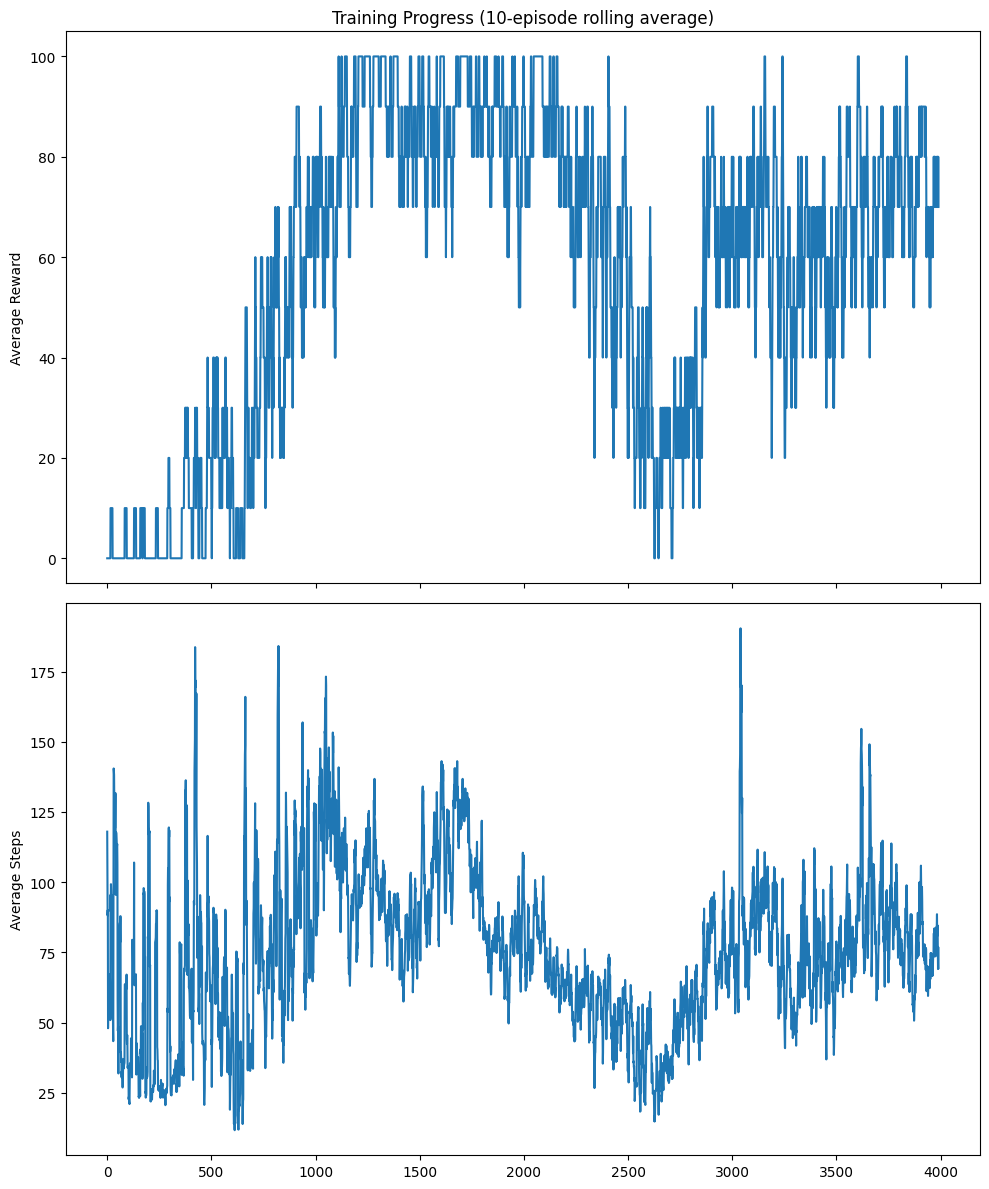

In [31]:
import matplotlib.pyplot as plt

# Calculate rolling averages
window_size = 10
rolling_rewards = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
rolling_steps = np.convolve(steps_history, np.ones(window_size)/window_size, mode='valid')
rolling_success = np.convolve([1 if s else 0 for s in success_history], np.ones(window_size)/window_size, mode='valid') * 100

# Create the plots
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Plot rewards
ax1.plot(rolling_rewards)
ax1.set_ylabel('Average Reward')
ax1.set_title('Training Progress (10-episode rolling average)')

# Plot steps
ax2.plot(rolling_steps)
ax2.set_ylabel('Average Steps')

# Plot success rate
#ax3.plot(rolling_success)
#ax3.set_ylabel('Success Rate (%)')
#ax3.set_xlabel('Episode')

plt.tight_layout()
plt.show()

In [32]:
# Turn off exploration for evaluation
dqn_agent = DQNAgent(learning_rate=0.0001, discount_factor=0.99, exploration_rate=0.8)
dqn_agent.load("best_sailing_model.pkl")
dqn_agent.exploration_rate = 0

# Create test environment
test_env = SailingEnv(**get_wind_scenario('training_1'))

# Test parameters
num_test_episodes = 5
max_steps = 500

print("Testing the trained agent on 5 new episodes...")
# Testing loop
for episode in range(num_test_episodes):
    # Reset environment
    observation, info = test_env.reset(seed=2500 + episode)  # Different seeds from training
    
    total_reward = 0
    
    for step in range(max_steps):
        # Select action using learned policy
        action = dqn_agent.act(observation)
        observation, reward, done, truncated, info = test_env.step(action)
        
        total_reward += reward
        
        # Break if episode is done
        if done or truncated:
            is_stuck = info.get('is_stuck', False)
            if is_stuck:
                print(f"Episode {episode+1}: CRASH dans l'île à l'étape {step+1}")
            elif done:
                print(f"Episode {episode+1}: VICTOIRE (Bouée touchée) à l'étape {step+1}")
            else:
                print(f"Episode {episode+1}: Temps expiré (Truncated)")
            break
    
    print(f"Test Episode {episode+1}: Steps={step+1}, Reward={total_reward}, " +
          f"Position={info['position']}, Goal reached={done}")

Testing the trained agent on 5 new episodes...
Episode 1: VICTOIRE (Bouée touchée) à l'étape 60
Test Episode 1: Steps=60, Reward=100.0, Position=[ 65 127], Goal reached=True
Episode 2: CRASH dans l'île à l'étape 24
Test Episode 2: Steps=24, Reward=0.0, Position=[39 44], Goal reached=True
Episode 3: VICTOIRE (Bouée touchée) à l'étape 62
Test Episode 3: Steps=62, Reward=100.0, Position=[ 63 127], Goal reached=True
Episode 4: VICTOIRE (Bouée touchée) à l'étape 64
Test Episode 4: Steps=64, Reward=100.0, Position=[ 64 127], Goal reached=True
Episode 5: VICTOIRE (Bouée touchée) à l'étape 60
Test Episode 5: Steps=60, Reward=100.0, Position=[ 63 127], Goal reached=True


In [33]:
# Import the utility function for saving DQN agents
from src.utils.agent_utils import save_dqn_agent

# Save our trained agent
save_dqn_agent(
    agent=dqn_agent,
    output_path="/home/onyxia/work/fork_stable_v2_RL_sailing_challenge/src/agents/agent_trained_dqn_first_version.py"
)

Agent saved to /home/onyxia/work/fork_stable_v2_RL_sailing_challenge/src/agents/agent_trained_dqn_first_version.py


In [35]:
import zipfile
import os

AGENT_FILE = "/home/onyxia/work/fork_stable_v2_RL_sailing_challenge/src/agents/agent_trained_dqn_first_version.py"
OUTPUT_ZIP = "../reward_dqn_first.zip"
if not os.path.exists(AGENT_FILE):
    print(f"Agent file not found: {AGENT_FILE}")
else:
    # Read the agent code and patch the import for Codabench
    with open(AGENT_FILE, "r") as f:
        code = f.read()

    # Replace local import with Codabench import
    code = code.replace(
        "from agents.base_agent import BaseAgent",
        "from evaluator.base_agent import BaseAgent",
    )

    # Write the submission zip with the .py file at the root
    with zipfile.ZipFile(OUTPUT_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
        zf.writestr("my_agent.py", code)

    print(f"Created {OUTPUT_ZIP}")
    print(f"Contents:")
    with zipfile.ZipFile(OUTPUT_ZIP, "r") as zf:
        for info in zf.infolist():
            print(f"  {info.filename} ({info.file_size} bytes)")

Created ../reward_dqn_first.zip
Contents:
  my_agent.py (976999 bytes)
